ayuda

In [97]:
import pandas as pd

data = '../data_2025/pib2020-2025.csv'
data2 = '../data_2025/WHO_life_expectancy.csv'

df1 = pd.read_csv(data)
df2 = pd.read_csv(data2)

display(df1.head())
display(df2.head())

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


In [98]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [99]:
df1.describe()

,2020,2021,2022,2023,2024,2025
count,1.960000e+02,1.940000e+02,1.940000e+02,1.940000e+02,1.920000e+02,1.890000e+02
mean,4.378886e+05,5.043504e+05,5.255064e+05,5.486173e+05,5.756871e+05,5.991414e+05
std,1.942936e+06,2.220864e+06,2.347886e+06,2.453040e+06,2.573189e+06,2.693421e+06
min,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,9.588000e+03,1.114175e+04,1.265000e+04,1.360450e+04,1.350050e+04,1.421400e+04
50%,3.533450e+04,3.771900e+04,4.156800e+04,4.363100e+04,4.713550e+04,4.782900e+04
75%,2.074810e+05,2.546132e+05,2.746308e+05,2.850355e+05,2.915108e+05,3.032930e+05
max,2.135412e+07,2.368118e+07,2.600690e+07,2.772072e+07,2.918490e+07,3.050722e+07


In [100]:
df1.isnull().sum()

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64

In [101]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location type        24420 non-null  object
 5   SpatialDimValueCode  24420 non-null  object
 6   Location             24420 non-null  object
 7   Period type          24420 non-null  object
 8   Period               24420 non-null  int64 
 9   Dim1 type            24420 non-null  object
 10  Dim1                 24420 non-null  object
 11  Value                24420 non-null  object
dtypes: int64(1), object(11)
memory usage: 2.2+ MB


In [102]:
df2.describe()

,Period
count,24420.000000
mean,2010.500000
std,6.344419
min,2000.000000
25%,2005.000000
50%,2010.500000
75%,2016.000000
max,2021.000000


In [103]:
df2.isnull().sum()

IndicatorCode          0
Indicator              0
ParentLocationCode     0
ParentLocation         0
Location type          0
SpatialDimValueCode    0
Location               0
Period type            0
Period                 0
Dim1 type              0
Dim1                   0
Value                  0
dtype: int64

# Crear las columnas a partir de la columna 'Value'

In [104]:
df2['Value_promedio'] = df2['Value'].apply(lambda x: x.split(' ')[0]).astype(float, errors='raise')

import numpy as np

def extraer_limite_inferior(valor_str):
    partes = valor_str.split(' ')

    if len(partes) > 1:
        rango_str = partes[1]
        try:
            limite_inferior = rango_str.strip('[]').split('-')[0]
            # 3. Limpiamos posibles caracteres no numéricos
            # 4. Lo convertimos a float
            return float(limite_inferior)
        except:
            # Si algo falla en la limpieza (ej. el texto era "[N/A]")
            return np.nan
    else:
        # Si no había parte [1] (no había rango), devolvemos NaN
        return np.nan

def extraer_limite_superior(valor_str):
    partes = valor_str.split(' ')

    if len(partes) > 1:
        rango_str = partes[1]
        try:
            limite_superior = rango_str.strip('[]').split('-')[1]
            # 3. Limpiamos posibles caracteres no numéricos
            # 4. Lo convertimos a float
            return float(limite_superior)
        except:
            # Si algo falla en la limpieza (ej. el texto era "[N/A]")
            return np.nan
    else:
        # Si no había parte [1] (no había rango), devolvemos NaN
        return np.nan

df2['Value_Limite_Inferior'] = df2['Value'].apply(extraer_limite_inferior)
df2['Value_limite_superior'] = df2['Value'].apply(extraer_limite_superior)
df2.drop(columns=['Value'], inplace=True)

df2

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value_promedio,Value_Limite_Inferior,Value_limite_superior
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7,47.8,49.7
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6,48.5,50.9
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5,50.5,52.6
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6,50.7,52.8
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7,50.6,53.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24415,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,CHE,Switzerland,Year,2000,Sex,Female,24.8,24.8,24.9
24416,WHOSIS_000015,Life expectancy at age 60 (years),WPR,Western Pacific,Country,AUS,Australia,Year,2000,Sex,Female,24.9,24.8,24.9
24417,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,FRA,France,Year,2000,Sex,Female,25.3,25.2,25.3
24418,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,NIC,Nicaragua,Year,2000,Sex,Female,25.6,25.5,25.7


In [105]:
columnas_drop = []

for col in df2:
    display(f'La columna {col} tiene {df2[col].nunique()} columnas y son: {df2[col].unique()}')
    if df2[col].nunique() == 1:
        columnas_drop.append(col)

"La columna IndicatorCode tiene 2 columnas y son: ['WHOSIS_000001' 'WHOSIS_000015']"

"La columna Indicator tiene 2 columnas y son: ['Life expectancy at birth (years)' 'Life expectancy at age 60 (years)']"

"La columna ParentLocationCode tiene 6 columnas y son: ['AFR' 'EMR' 'WPR' 'AMR' 'SEAR' 'EUR']"

"La columna ParentLocation tiene 6 columnas y son: ['Africa' 'Eastern Mediterranean' 'Western Pacific' 'Americas'\n 'South-East Asia' 'Europe']"

"La columna Location type tiene 1 columnas y son: ['Country']"

...

"La columna Dim1 type tiene 1 columnas y son: ['Sex']"

"La columna Dim1 tiene 3 columnas y son: ['Male' 'Both sexes' 'Female']"

'La columna Value_promedio tiene 649 columnas y son: [48.7 49.6 51.5 51.6 51.7 52.3 54.  54.6 54.8 55.4 56.1 56.2 56.3 56.5\n 57.3 57.4 57.5 57.7 57.8 57.9 58.5 58.6 58.7 58.9 59.  59.1 59.2 59.4\n 59.7 59.9 60.  60.2 60.4 60.5 60.6 60.7 60.9 61.  61.1 61.2 61.3 61.4\n 61.5 61.6 61.7 61.8 61.9 62.  62.1 62.2 62.3 62.5 62.6 62.7 62.9 63.\n 63.1 63.2 63.4 63.5 63.6 63.7 63.8 63.9 64.  64.2 64.3 64.4 64.6 64.7\n 64.8 64.9 65.1 65.2 65.3 65.4 65.5 65.6 65.7 65.8 65.9 66.  66.1 66.2\n 66.3 66.4 66.5 66.7 66.8 66.9 67.  67.2 67.3 67.4 67.5 67.6 67.7 67.8\n 67.9 68.  68.1 68.2 68.3 68.4 68.5 68.6 68.7 68.8 68.9 69.  69.1 69.2\n 69.3 69.4 69.5 69.6 69.7 69.8 69.9 70.  70.1 70.2 70.3 70.4 70.5 70.6\n 70.8 70.9 71.  71.1 71.2 71.3 71.4 71.5 71.6 71.7 71.8 71.9 72.2 72.3\n 72.4 72.5 72.6 72.7 72.8 72.9 73.  73.1 73.2 73.3 73.4 73.5 73.6 73.7\n 73.8 73.9 74.  74.1 74.2 74.3 74.4 74.5 74.6 74.7 74.8 74.9 75.  75.1\n 75.2 75.3 75.4 75.5 75.6 75.7 75.8 75.9 76.  76.2 76.4 76.5 76.6 76.7\n 76.8 76.9 7

'La columna Value_Limite_Inferior tiene 666 columnas y son: [47.8 48.5 50.5 50.7 50.6 51.1 52.9 53.3 53.5 53.8 54.1 55.  55.3 54.9\n 56.5 56.6 56.3 56.8 57.8 57.2 57.7 58.5 57.9 58.3 58.  58.4 59.  58.9\n 58.7 59.1 59.6 59.8 59.3 59.7 59.9 60.  60.1 60.2 60.3 60.6 61.1 60.8\n 60.5 61.  60.9 61.2 61.6 61.4 61.5 61.7 61.8 61.3 62.  62.1 62.3 62.2\n 62.4 62.5 62.6 62.8 62.7 62.9 63.  63.2 63.3 63.7 63.4 63.5 63.8 64.\n 63.9 64.3 64.6 64.5 64.8 64.9 64.7 65.2 65.1 65.6 65.3 65.  65.5 65.7\n 65.8 66.  66.1 65.9 66.2 66.7 67.  66.5 66.9 66.8 67.1 67.2 67.8 67.5\n 67.4 67.6 67.9 68.1 68.4 67.7 68.3 68.2 68.5 68.6 68.8 68.7 69.2 68.9\n 69.1 69.5 69.  69.3 69.4 69.6 70.  69.7 69.9 69.8 70.2 70.4 70.7 70.5\n 70.6 70.9 70.3 70.8 71.1 71.2 71.  71.4 71.5 71.3 71.6 71.7 71.8 72.2\n 72.1 71.9 72.  72.4 72.6 72.7 72.8 72.5 72.9 73.1 73.  73.4 73.3 73.7\n 73.2 73.6 73.8 74.  74.1 74.3 73.9 74.4 74.5 74.6 74.2 74.9 74.8  nan\n 74.7 75.2 75.1 75.4 75.3 75.5 75.6 75.7 75.8 76.  76.1 76.3 76.2 76.5\n 76.6

'La columna Value_limite_superior tiene 634 columnas y son: [49.7 50.9 52.6 52.8 53.1 53.4 55.1 56.  55.9 55.8 56.6 57.2 57.  57.5\n 58.  58.2 58.9 58.8 59.7 59.4 59.8 60.6 60.4 59.9 60.1 60.8 60.9 61.2\n 61.1 61.8 61.5 61.4 61.9 61.7 62.2 62.3 62.1 62.4 62.8 63.3 62.5 63.\n 62.7 63.1 63.2 63.6 63.5 63.7 63.4 64.  63.9 64.1 63.8 64.3 64.2 64.8\n 64.6 64.4 64.7 64.5 65.  64.9 65.1 65.4 65.2 65.6 65.7 66.  65.9 66.2\n 66.1 66.4 66.5 66.6 66.8 66.9 66.7 67.1 67.  67.2 67.4 67.3 67.5 67.7\n 67.6 67.9 68.  68.2 67.8 68.4 68.3 68.5 68.6 68.7 69.1 69.  69.2 68.9\n 69.5 69.3 69.4 69.6 69.7 69.8 70.1 70.5 70.2 70.3 70.  69.9 70.4 70.9\n 70.6 71.  70.7 70.8 71.2 71.4 71.3 71.1 71.9 71.5 72.  71.6 71.7 71.8\n 72.2 72.3 72.4 72.7 72.8 72.5 73.3 72.6 73.2 73.1 72.9 73.4 73.  73.7\n 73.5 73.6 73.8 74.  73.9 74.3 74.4 74.2 74.8 74.6 74.5 74.1 74.7 75.7\n 74.9 75.1 75.2 75.4 75.  75.3 75.5 75.6 75.9  nan 76.2 76.1 76.4 76.\n 75.8 76.5 76.7 76.8 76.9 76.6 77.1 77.  77.4 77.5 77.2 77.3 78.5 77.9\n 77.8 

In [106]:
print(f'Columnas a eliminar: {columnas_drop}')
# Eliminamos las columnas que solo tienen un valor único
df2.drop(columns=columnas_drop, inplace=True)

Columnas a eliminar: ['Location type', 'Period type', 'Dim1 type']


In [107]:
df2.duplicated().sum()

np.int64(0)

# Tenemos una posible variable a predecir, ya que tiene solo 3 valores únicos que podríamos clasificar de alguna forma

In [108]:
var_y_posible = 'Dim1'

No podemos eliminar nada en el primer df, esto porque haremos un merge junto al otro df para trabajar mejor los datos

In [109]:
columnas_drop = []

for col in df1:
    display(f'La columna {col} tiene {df1[col].nunique()} columnas y son: {df1[col].unique()}')
    if df1[col].nunique() == 1:
        columnas_drop.append(col)

"La columna Country tiene 196 columnas y son: ['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'\n 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'\n 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'\n 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'\n 'Botswana' 'Brazil' 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi'\n 'Cape Verde' 'Cambodia' 'Cameroon' 'Canada' 'Central African Republic'\n 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'\n 'Democratic Republic of the Congo' 'Republic of the Congo' 'Costa Rica'\n 'Ivory Coast' 'Croatia' 'Cyprus' 'Czech Republic' 'Denmark' 'Djibouti'\n 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'\n 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji'\n 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece'\n 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'\n 'Honduras' 'Hong Kong' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran'

'La columna 2020 tiene 196 columnas y son: [   20136    15271   164774     2885    66521     1412   385218    12642\n     2486  1362613   434050    42693     9958    35838   373902     5168\n    61312   529269     2043    15674     2586    36897    20226    14930\n  1476092    12006    70658    17837     3089     1831    34898    40863\n  1655685     2389    14954   254060 15103357   270348     1218    49613\n    11485    62382    63119    57919    25535   251110   355631     3144\n      504    78625    95865   382525    24921     9908     1982    31795\n     3984    96611     4432   269784  2645806    15364     1809    16013\n  3936989    70008   191210     1043    77718    14089     1523     5471\n    14508    23190   344941   158468    21630  2674852  1059055   195528\n   182576   436205   410771  1905956    13885  5054069    43762   171082\n   100912      222  1744456     7728   111048     8283    18511    33353\n    24976     2092     3037    46893    57352    73612    25344    13

'La columna 2021 tiene 194 columnas y son: [1.4278000e+04 1.8086000e+04 1.8585000e+05 3.3250000e+03 8.4375000e+04\n 1.6020000e+03 4.8604000e+05 1.3879000e+04 2.9290000e+03 1.6558430e+06\n 4.8078600e+05 5.4825000e+04 1.1369000e+04 4.0840000e+04 4.1626500e+05\n 5.2750000e+03 6.8207000e+04 5.9889200e+05 2.4210000e+03 1.7699000e+04\n 2.6230000e+03 4.0701000e+04 2.3673000e+04 1.8750000e+04 1.6706500e+06\n 1.4006000e+04 8.4477000e+04 1.9747000e+04 3.3560000e+03 2.0530000e+03\n 3.6797000e+04 4.5036000e+04 2.0223820e+06 2.5850000e+03 1.6881000e+04\n 3.1541100e+05 1.8190803e+07 3.1852500e+05 1.2730000e+03 5.5327000e+04\n 1.3387000e+04 6.4954000e+04 7.2833000e+04 6.9055000e+04 3.0393000e+04\n 2.9097300e+05 4.0837800e+05 3.3930000e+03 5.5500000e+02 9.5067000e+04\n 1.0717900e+05 4.2330000e+05 2.9043000e+04 1.2222000e+04           nan\n 3.7229000e+04 4.8510000e+03 9.9261000e+04 4.3050000e+03 2.9441900e+05\n 2.9684050e+06 1.9455000e+04 2.0450000e+03 1.8849000e+04 4.3511880e+06\n 7.9514000e+04 2.1844

'La columna 2022 tiene 194 columnas y son: [1.4501000e+04 1.9185000e+04 2.2570900e+05 3.3760000e+03 1.4244200e+05\n 1.8670000e+03 6.3231800e+05 1.9514000e+04 3.2790000e+03 1.7254610e+06\n 4.7233900e+05 7.8807000e+04 1.3136000e+04 4.6458000e+04 4.6020100e+05\n 6.2570000e+03 7.3735000e+04 5.9390600e+05 2.8470000e+03 1.7439000e+04\n 2.8690000e+03 4.4329000e+04 2.4535000e+04 2.0321000e+04 1.9518490e+06\n 1.6682000e+04 9.0719000e+04 1.9588000e+04 3.9220000e+03 2.3090000e+03\n 3.9838000e+04 4.4442000e+04 2.1904110e+06 2.4600000e+03 1.7867000e+04\n 3.0127000e+05 1.8307816e+07 3.4563200e+05 1.2230000e+03 6.3324000e+04\n 1.3967000e+04 6.9235000e+04 7.1075000e+04 7.1260000e+04 3.1001000e+04\n 3.0183100e+05 4.0194600e+05 3.5630000e+03 6.0700000e+02 1.1381300e+05\n 1.1613300e+05 4.7523100e+05 3.1989000e+04 1.3717000e+04           nan\n 3.8406000e+04 4.7910000e+03 1.1895800e+05 4.9700000e+03 2.8047400e+05\n 2.7970490e+06 2.0485000e+04 2.1350000e+03 2.4985000e+04 4.1668720e+06\n 7.3919000e+04 2.1905

'La columna 2023 tiene 194 columnas y son: [1.7248000e+04 2.3388000e+04 2.4778900e+05 3.7860000e+03 1.0976400e+05\n 2.0060000e+03 6.4551100e+05 2.4086000e+04 3.6490000e+03 1.7424610e+06\n 5.1250900e+05 7.2428000e+04 1.4338000e+04 4.6192000e+04 4.5153400e+05\n 6.7210000e+03 7.1792000e+04 6.4496800e+05 3.0670000e+03 1.9679000e+04\n 2.9230000e+03 4.5464000e+04 2.7592000e+04 1.9411000e+04 2.1911370e+06\n 1.5095000e+04 1.0243400e+05 2.1181000e+04 4.2460000e+03 2.5880000e+03\n 4.3304000e+04 4.9283000e+04 2.1733400e+06 2.6020000e+03 1.8343000e+04\n 3.3562700e+05 1.8270351e+07 3.6629200e+05 1.3350000e+03 6.4402000e+04\n 1.4169000e+04 8.6509000e+04 7.9630000e+04 8.4416000e+04 3.3897000e+04\n 3.4320700e+05 4.0709200e+05 3.9170000e+03 6.5400000e+02 1.2079400e+05\n 1.2114700e+05 3.9382800e+05 3.4016000e+04 1.2339000e+04           nan\n 4.1303000e+04 4.8580000e+03 1.5976100e+05 5.4420000e+03 2.9503600e+05\n 3.0568800e+06 2.0059000e+04 2.3450000e+03 3.0778000e+04 4.5270090e+06\n 8.0547000e+04 2.4356

'La columna 2024 tiene 192 columnas y son: [          nan 2.7259000e+04 2.6491300e+05 4.0380000e+03 1.1594600e+05\n 2.2250000e+03 6.3214500e+05 2.5533000e+04 3.9520000e+03 1.7968050e+06\n 5.2126900e+05 7.4316000e+04 1.4761000e+04 4.6943000e+04 4.5109600e+05\n 7.1670000e+03 7.1180000e+04 6.6496500e+05 3.4270000e+03 2.1249000e+04\n 3.0920000e+03 4.8404000e+04 2.8795000e+04 1.9356000e+04 2.1713370e+06\n 1.5463000e+04 1.1223200e+05 2.3975000e+04 4.7430000e+03 2.7260000e+03\n 4.7328000e+04 5.2784000e+04 2.2412530e+06 2.8310000e+03 1.9078000e+04\n 3.3021000e+05 1.8748009e+07 4.1854200e+05 1.4560000e+03 7.1011000e+04\n 1.4893000e+04 9.5365000e+04 8.7096000e+04 9.2506000e+04 3.6156000e+04\n 3.4493100e+05 4.2945800e+05 4.2570000e+03 6.9700000e+02 1.2461300e+05\n 1.2172800e+05 3.8310900e+05 3.5337000e+04 1.2544000e+04 4.2752000e+04\n 5.1990000e+03 1.4312300e+05 5.9490000e+03 2.9883300e+05 3.1620230e+06\n 2.0774000e+04 2.5580000e+03 3.3775000e+04 4.6585260e+06 8.2825000e+04\n 2.5706700e+05 1.3920

'La columna 2025 tiene 188 columnas y son: [          nan 2.8372000e+04 2.6888500e+05 4.0350000e+03 1.1334300e+05\n 2.3730000e+03 6.8353300e+05 2.6258000e+04 4.1000000e+03 1.7716810e+06\n 5.3430100e+05 7.8870000e+04 1.5178000e+04 4.7829000e+04 4.6721800e+05\n 7.5520000e+03 7.1561000e+04 6.8486400e+05 3.6110000e+03 2.2236000e+04\n 3.4220000e+03 5.6339000e+04 2.8807000e+04 1.9400000e+04 2.1259580e+06\n 1.6007000e+04 1.1700700e+05 2.7056000e+04 6.7450000e+03 2.7860000e+03\n 4.9799000e+04 5.6011000e+04 2.2253410e+06 2.9320000e+03 1.8792000e+04\n 3.4382300e+05 1.9231705e+07 4.2776600e+05 1.5480000e+03 7.9119000e+04\n 1.5281000e+04 1.0259100e+05 9.4483000e+04 9.8951000e+04 3.8736000e+04\n 3.6024400e+05 4.4994000e+05 4.5870000e+03 7.4200000e+02 1.2782800e+05\n 1.2567700e+05 3.4734200e+05 3.6749000e+04 1.2684000e+04 4.5004000e+04\n 5.4830000e+03 1.1745700e+05 6.2570000e+03 3.0394500e+05 3.2112920e+06\n 2.0391000e+04 2.7710000e+03 3.5353000e+04 4.7448040e+06 8.8332000e+04\n 2.6734800e+05 1.4640

In [123]:
# Usamos el inner join para quedarnos solo con los países que están en ambos dataframes
df_unified = pd.merge(df1, df2, left_on='Country', right_on='Location', how='inner')
df_unified.sample(5)

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,SpatialDimValueCode,Location,Period,Dim1,Value_promedio,Value_Limite_Inferior,Value_limite_superior
18581,Sudan,35237,35142.0,33517.0,36998.0,28270.0,31506.0,WHOSIS_000015,Life expectancy at age 60 (years),EMR,Eastern Mediterranean,SDN,Sudan,2005,Female,18.3,17.7,19.0
9127,Iraq,182576,210753.0,288059.0,270799.0,277478.0,258020.0,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,IRQ,Iraq,2018,Both sexes,73.1,72.3,74.1
15152,Paraguay,35432,39951.0,41953.0,43118.0,43989.0,45465.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,PRY,Paraguay,2004,Female,77.2,76.7,77.9
10105,Kazakhstan,171082,197112.0,225496.0,261840.0,284810.0,300538.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,KAZ,Kazakhstan,2009,Both sexes,68.5,68.3,68.8
10571,Kyrgyzstan,8283,9256.0,12269.0,15187.0,17491.0,19849.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,KGZ,Kyrgyzstan,2020,Female,19.6,19.3,20.0


In [111]:
df_unified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21252 entries, 0 to 21251
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                21252 non-null  object 
 1   2020                   21252 non-null  int64  
 2   2021                   21120 non-null  float64
 3   2022                   21120 non-null  float64
 4   2023                   21120 non-null  float64
 5   2024                   20988 non-null  float64
 6   2025                   20592 non-null  float64
 7   IndicatorCode          21252 non-null  object 
 8   Indicator              21252 non-null  object 
 9   ParentLocationCode     21252 non-null  object 
 10  ParentLocation         21252 non-null  object 
 11  SpatialDimValueCode    21252 non-null  object 
 12  Location               21252 non-null  object 
 13  Period                 21252 non-null  int64  
 14  Dim1                   21252 non-null  object 
 15  Va

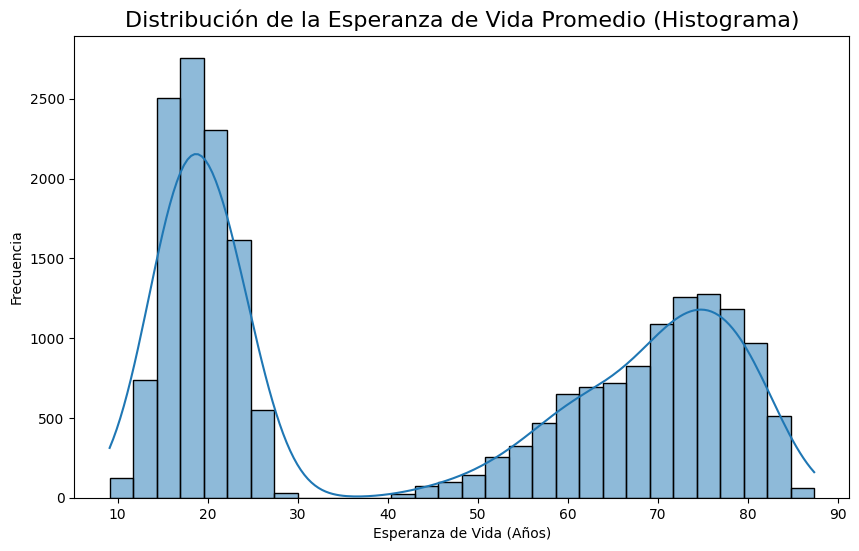

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_unified['Value_promedio'], kde=True, bins=30)
plt.title('Distribución de la Esperanza de Vida Promedio (Histograma)', fontsize=16)
plt.xlabel('Esperanza de Vida (Años)')
plt.ylabel('Frecuencia')
plt.show()

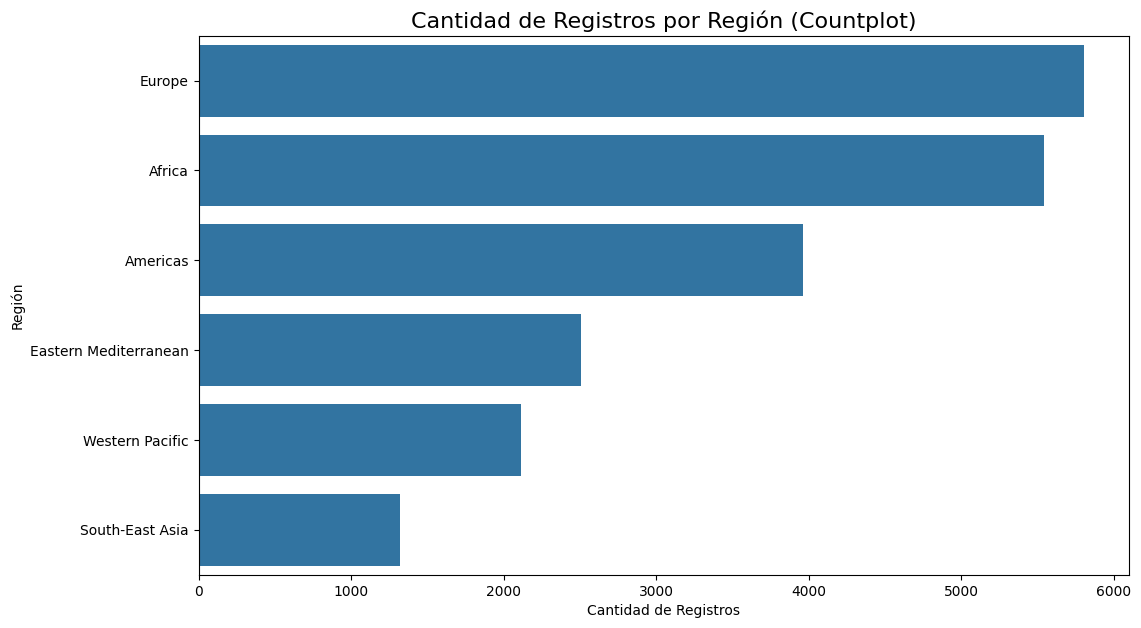

Gráfico 2 (Conteo) guardado como 'eda_2_conteo_region.png'


In [113]:
# B. Análisis Univariado: ¿Cuántos datos hay por región?
# (Visto en Clase 16)
plt.figure(figsize=(12, 7))
# Hacemos un countplot, y ordenamos por la cantidad de datos
sns.countplot(data=df_unified, y='ParentLocation', order = df_unified['ParentLocation'].value_counts().index)
plt.title('Cantidad de Registros por Región (Countplot)', fontsize=16)
plt.xlabel('Cantidad de Registros')
plt.ylabel('Región')
plt.show()
print("Gráfico 2 (Conteo) guardado como 'eda_2_conteo_region.png'")

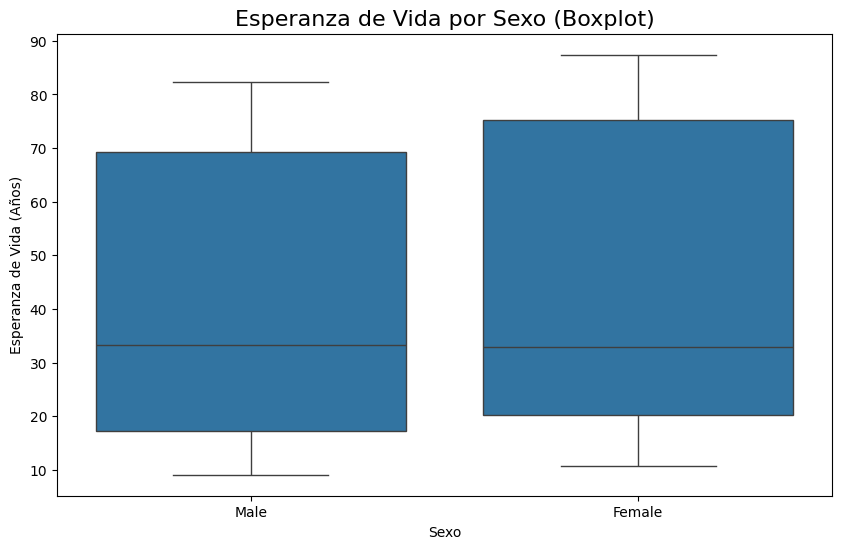

Gráfico 3 (Boxplot) guardado como 'eda_3_boxplot_sexo.png'


In [114]:

# C. Análisis Bivariado: ¿Cómo se compara la esperanza de vida entre sexos?
# (Visto en Clase 16)
# Filtramos "Both sexes" para una comparación justa entre Male y Female
df_sexos = df_unified[df_unified['Dim1'] != 'Both sexes']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sexos, x='Dim1', y='Value_promedio')
plt.title('Esperanza de Vida por Sexo (Boxplot)', fontsize=16)
plt.xlabel('Sexo')
plt.ylabel('Esperanza de Vida (Años)')
plt.show()
print("Gráfico 3 (Boxplot) guardado como 'eda_3_boxplot_sexo.png'")

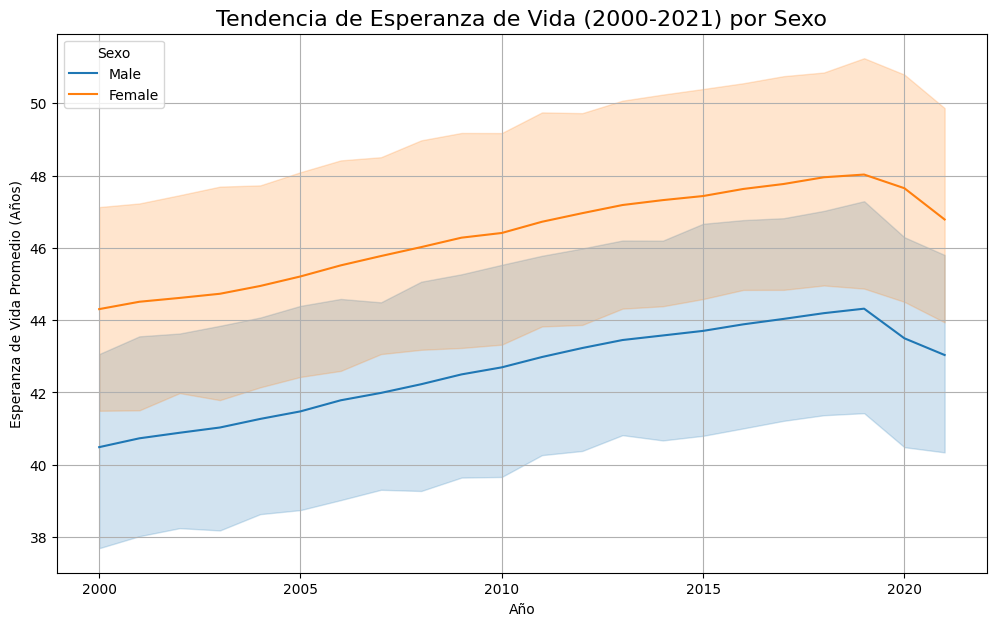

Gráfico 4 (Lineplot) guardado como 'eda_4_lineplot_tendencia.png'


In [115]:
# D. Análisis Multivariado: ¿Cómo ha cambiado la esperanza de vida a través del tiempo, separada por sexo?
# (Visto en Clase 16 - usando 'hue')
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_sexos, x='Period', y='Value_promedio', hue='Dim1')
plt.title('Tendencia de Esperanza de Vida (2000-2021) por Sexo', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Esperanza de Vida Promedio (Años)')
plt.legend(title='Sexo')
plt.grid(True)
plt.show()
print("Gráfico 4 (Lineplot) guardado como 'eda_4_lineplot_tendencia.png'")


          ParentLocation  Region_code        Dim1  Sexo_code     Location  \
0  Eastern Mediterranean            0        Male          0  Afghanistan   
1  Eastern Mediterranean            0  Both sexes          1  Afghanistan   
2  Eastern Mediterranean            0      Female          2  Afghanistan   
3  Eastern Mediterranean            0        Male          0  Afghanistan   
4  Eastern Mediterranean            0  Both sexes          1  Afghanistan   

   Pais_code  
0          0  
1          0  
2          0  
3          0  
4          0  
Matriz de Correlación:
                       Value_Limite_Inferior  Value_limite_superior  \
Value_Limite_Inferior               1.000000               0.999674   
Value_limite_superior               0.999674               1.000000   
Period                              0.041118               0.043077   
Value_promedio                      0.999921               0.999912   
Region_code                        -0.012020              -0.010808  

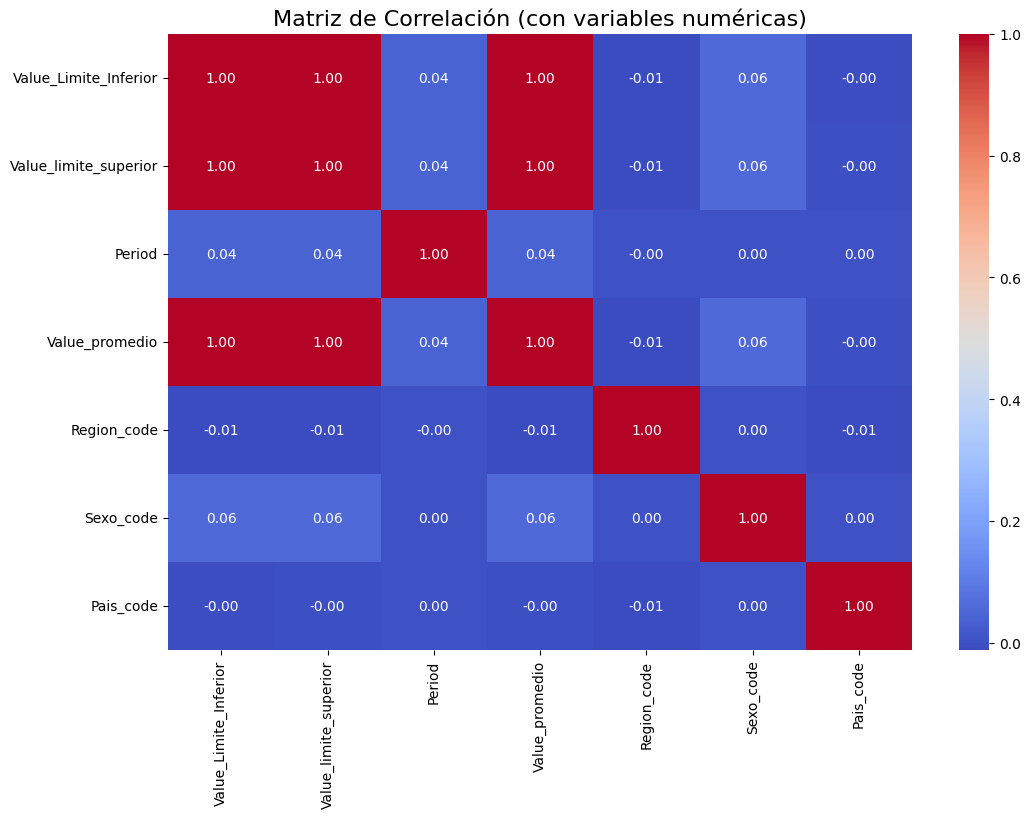

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copiamos el dataframe para no modificar el original
df_numeric = df_unified.copy()

# Columnas clave de texto (object) que convertiremos:
# 'ParentLocation' (Región), 'Dim1' (Sexo), y 'Location' (País)

# pd.factorize() devuelve un array de códigos numéricos (índice [0])
df_numeric['Region_code'] = pd.factorize(df_numeric['ParentLocation'])[0]
df_numeric['Sexo_code'] = pd.factorize(df_numeric['Dim1'])[0]
df_numeric['Pais_code'] = pd.factorize(df_numeric['Location'])[0]

print(df_numeric[['ParentLocation', 'Region_code', 'Dim1', 'Sexo_code', 'Location', 'Pais_code']].head())

# Ahora sí podemos incluir las nuevas columnas numéricas en la correlación
columnas_para_correlacion = [
    'Value_Limite_Inferior',
    'Value_limite_superior',
    'Period', 
    'Value_promedio', 
    'Region_code',  # <-- Nueva
    'Sexo_code',      # <-- Nueva
    'Pais_code'       # <-- Nueva
]

# Calculamos la matriz de correlación
corr_matrix_full = df_numeric[columnas_para_correlacion].corr()

print("Matriz de Correlación:")
print(corr_matrix_full)

# Graficamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_full, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación (con variables numéricas)', fontsize=16)
plt.show()

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error


y = df_unified['Value_promedio']

# Columnas que usaremos para predecir
X_pre = df_unified[['Period', 'ParentLocation', 'Dim1']]

# Pasamos de texto a números
X = pd.get_dummies(X_pre, columns=['ParentLocation', 'Dim1'], drop_first=True)

display(X.head())

,Period,ParentLocation_Americas,ParentLocation_Eastern Mediterranean,ParentLocation_Europe,ParentLocation_South-East Asia,ParentLocation_Western Pacific,Dim1_Female,Dim1_Male
0,2021,False,True,False,False,False,False,True
1,2021,False,True,False,False,False,False,False
2,2021,False,True,False,False,False,True,False
3,2021,False,True,False,False,False,False,True
4,2021,False,True,False,False,False,False,False


In [118]:
# Dividimos los datos en entrenamiento y prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"\nDatos divididos: {len(X_train)} para entrenamiento, {len(X_test)} para prueba.")


model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Evaluación
y_pred_lr = model_lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("\n--- Modelo 1: Regresión Lineal ---")
print(f"R2 en set de prueba: {r2_lr:.4f}")
print(f"RMSE en set de prueba: {rmse_lr:.2f} años")


Datos divididos: 14876 para entrenamiento, 6376 para prueba.

--- Modelo 1: Regresión Lineal ---
R2 en set de prueba: 0.0306
RMSE en set de prueba: 25.96 años


In [119]:
# Creamos un Pipeline: (1) Normaliza los datos, (2) Aplica KNN
pipeline_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor())])

# Definimos la "grilla" de hiperparámetros (k) a probar
param_grid_knn = {'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15]}

# Usamos GridSearchCV para encontrar el mejor 'k' usando Validación Cruzada
grid_search_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, scoring='r2', n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

print(f"Mejor 'k' encontrado por GridSearch: {grid_search_knn.best_params_['knn__n_neighbors']}")

# Evaluación del mejor modelo KNN
best_model_knn = grid_search_knn.best_estimator_
y_pred_knn = best_model_knn.predict(X_test)
r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

# --- 6. COMPARACIÓN FINAL ---
print("\n--- ✨ Comparación de Modelos (en set de prueba) ✨ ---")
print(f"Regresión Lineal:\t R2 = {r2_lr:.4f} \t RMSE = {rmse_lr:.2f} años")
print(f"Mejor KNN (k={grid_search_knn.best_params_['knn__n_neighbors']}):\t R2 = {r2_knn:.4f} \t RMSE = {rmse_knn:.2f} años")

Mejor 'k' encontrado por GridSearch: 15

--- ✨ Comparación de Modelos (en set de prueba) ✨ ---
Regresión Lineal:	 R2 = 0.0306 	 RMSE = 25.96 años
Mejor KNN (k=15):	 R2 = -0.0447 	 RMSE = 26.95 años
